In [1]:

import math
import numpy
import torch    # pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
import graphviz
import matplotlib

%matplotlib inline
numpy.set_printoptions(suppress=True)

In [2]:
def _tensor_label(name, tensor):
    data = tensor.detach()
    if data.numel() == 1:
        data_repr = f"{data.item():.4f}"
    else:
        data_repr = str(data.cpu().numpy())

    if tensor.grad is None:
        grad_repr = "None"
    else:
        grad = tensor.grad.detach()
        if grad.numel() == 1:
            grad_repr = f"{grad.item():.4f}"
        else:
            grad_repr = str(grad.cpu().numpy())

    return f"{{ {name} | data {data_repr} | grad {grad_repr} }}"


def retain_grads(*tensors):
    for tensor in tensors:
        if tensor is not None and not tensor.is_leaf:
            tensor.retain_grad()


def draw_dot_torch(root, named_tensors=None, format="svg", rankdir="LR"):
    """
    Visualize the PyTorch autograd graph with tensor data and grad values.


    named_tensors: optional mapping of display name -> tensor. Include
    intermediates here if you want them rendered with their values.
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ["LR", "TB"]

    named_tensors = dict(named_tensors or {})
    if "output" not in named_tensors.values() and root not in named_tensors.values():
        named_tensors["output"] = root

    tensor_names = {id(tensor): name for name, tensor in named_tensors.items()}
    fn_to_tensor = {tensor.grad_fn: tensor for tensor in named_tensors.values() if tensor.grad_fn is not None}

    dot = graphviz.Digraph(format=format, graph_attr={"rankdir": rankdir})
    seen_fns = set()
    seen_tensors = set()

    def add_tensor_node(tensor):
        tensor_id = str(id(tensor))
        if tensor_id in seen_tensors:
            return tensor_id

        name = tensor_names.get(id(tensor), "leaf" if tensor.is_leaf else "tensor")
        dot.node(name=tensor_id, label=_tensor_label(name, tensor), shape="record")
        seen_tensors.add(tensor_id)
        return tensor_id

    def add_fn(fn):
        if fn is None or fn in seen_fns:
            return
        seen_fns.add(fn)

        fn_id = f"fn_{id(fn)}"
        dot.node(name=fn_id, label=type(fn).__name__, shape="ellipse")

        fn_tensor = fn_to_tensor.get(fn)
        if fn_tensor is not None:
            dot.edge(fn_id, add_tensor_node(fn_tensor))

        for child, _ in fn.next_functions:
            if child is None:
                continue

            if hasattr(child, "variable"):
                dot.edge(add_tensor_node(child.variable), fn_id)
                continue

            add_fn(child)

            child_tensor = fn_to_tensor.get(child)
            if child_tensor is not None:
                dot.edge(add_tensor_node(child_tensor), fn_id)
            else:
                dot.edge(f"fn_{id(child)}", fn_id)

    if root.grad_fn is None:
        add_tensor_node(root)
    else:
        add_fn(root.grad_fn)

    return dot

In [3]:
print(torch.Tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]))
print(torch.Tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]).shape)
print(torch.Tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]).dtype)
print(torch.Tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]).double().dtype)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])
torch.float32
torch.float64


In [4]:
x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True

x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True

w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

retain_grads(n, o)  # retain intermediate grads for visualization

print(o.data.item())

o.backward()

print("---")
print(f"x1.grad: {x1.grad.item()}")
print(f"x2.grad: {x2.grad.item()}")
print(f"w1.grad: {w1.grad.item()}")
print(f"w2.grad: {w2.grad.item()}")
print(f"b.grad: {b.grad.item()}")
print(f"n.grad: {n.grad.item()}")
print(f"o.grad: {o.grad.item()}")

0.7071066904050358
---
x1.grad: -1.5000003851533106
x2.grad: 0.5000001283844369
w1.grad: 1.0000002567688737
w2.grad: 0.0
b.grad: 0.5000001283844369
n.grad: 0.5000001283844369
o.grad: 1.0


In [5]:
print(o)
print(o.item())
print(o.data.item())

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
0.7071066904050358
0.7071066904050358


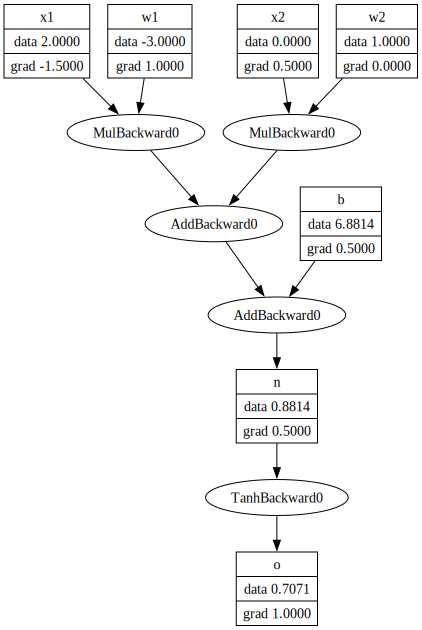

In [6]:
draw_dot_torch(
    o,
    named_tensors={
        "x1": x1,
        "x2": x2,
        "w1": w1,
        "w2": w2,
        "b": b,
        "n": n,
        "o": o,
    },
    rankdir="TB",
)